**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Injestion**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Stock_Price_Prediction/NFLX (2).csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


**EDA**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [4]:
df.shape

(1009, 7)

In [5]:
# Changing the column names into lowercase
df.columns = df.columns.str.lower()

In [6]:
# Seperating the date columns values in different columns (year,month,day)
df[['year','month','day']] = df['date'].apply(lambda x: pd.Series(map(int,x.split('-'))))

In [7]:
# Now dropping the date column
df.drop('date',axis=1,inplace=True)

In [8]:
df

,open,high,low,close,adj close,volume,year,month,day
0,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,2018,2,5
1,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,2018,2,6
2,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,2018,2,7
3,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,2018,2,8
4,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,2018,2,9
...,...,...,...,...,...,...,...,...,...
1004,401.970001,427.700012,398.200012,427.140015,427.140015,20047500,2022,1,31
1005,432.959991,458.480011,425.540009,457.130005,457.130005,22542300,2022,2,1
1006,448.250000,451.980011,426.480011,429.480011,429.480011,14346000,2022,2,2
1007,421.440002,429.260010,404.279999,405.600006,405.600006,9905200,2022,2,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       1009 non-null   float64
 1   high       1009 non-null   float64
 2   low        1009 non-null   float64
 3   close      1009 non-null   float64
 4   adj close  1009 non-null   float64
 5   volume     1009 non-null   int64  
 6   year       1009 non-null   int64  
 7   month      1009 non-null   int64  
 8   day        1009 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 71.1 KB


In [10]:
# Checking for Null values

df.isnull().sum()

,0
open,0
high,0
low,0
close,0
adj close,0
volume,0
year,0
month,0
day,0


In [12]:
df.isnull().sum().any()

np.False_

In [11]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

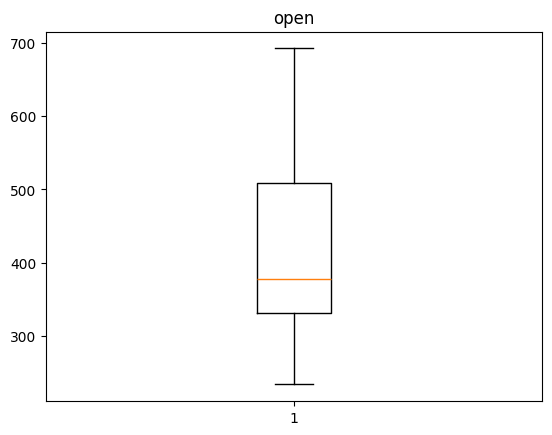

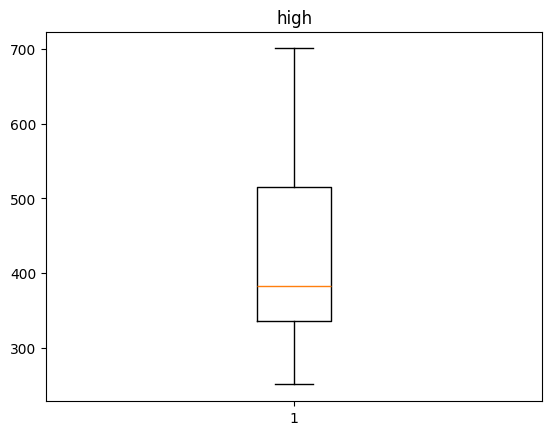

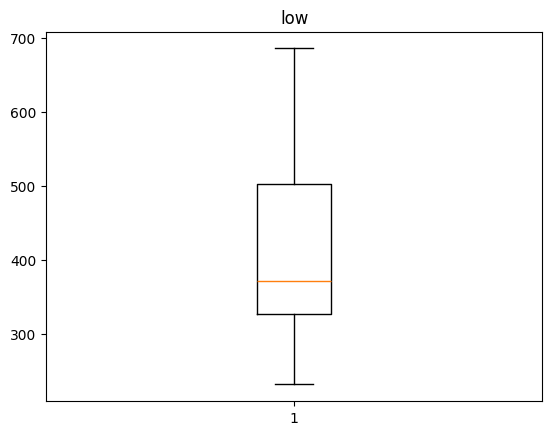

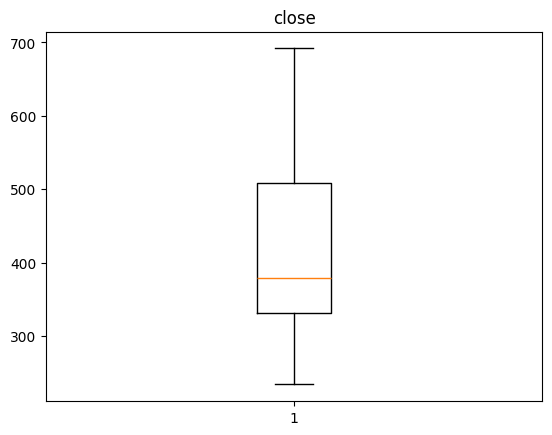

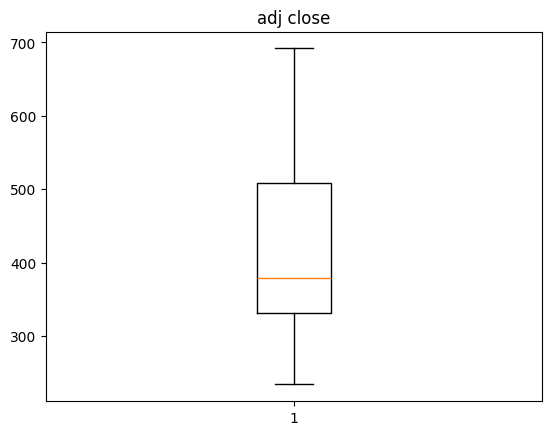

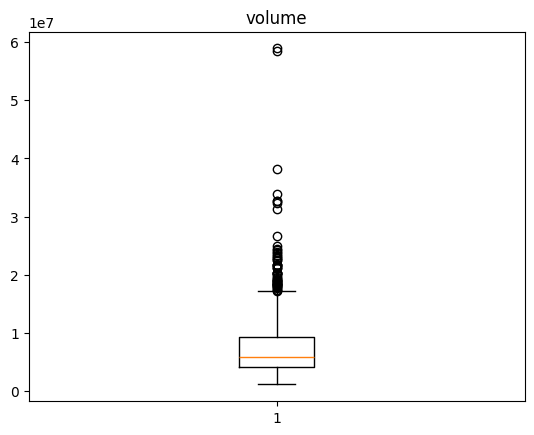

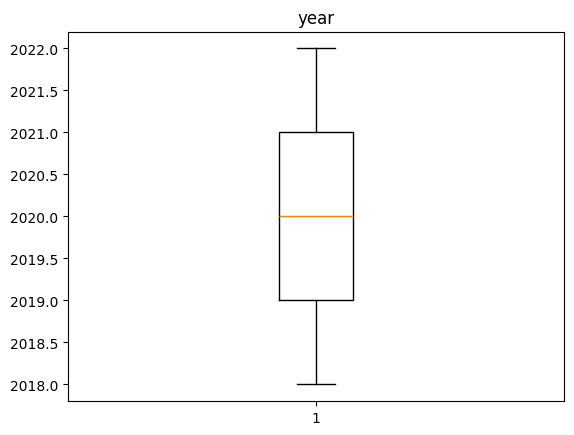

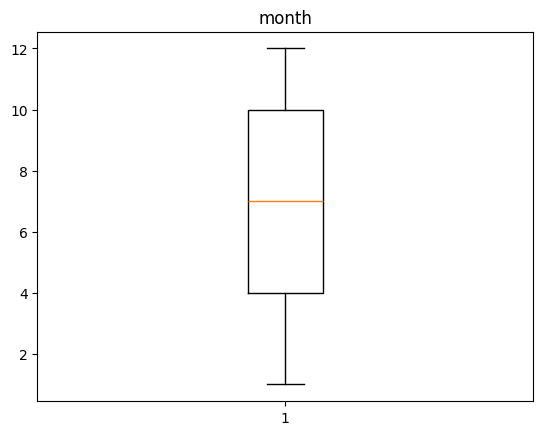

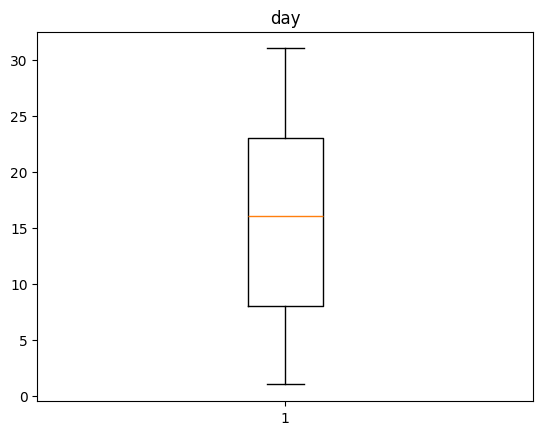

In [14]:
# Outlier Analysis

for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(data=df,x=col)
    plt.title(col)
    plt.show()

Only volume column has outliers but we cannot remove them as we know there is no limit to the volume of the stock.

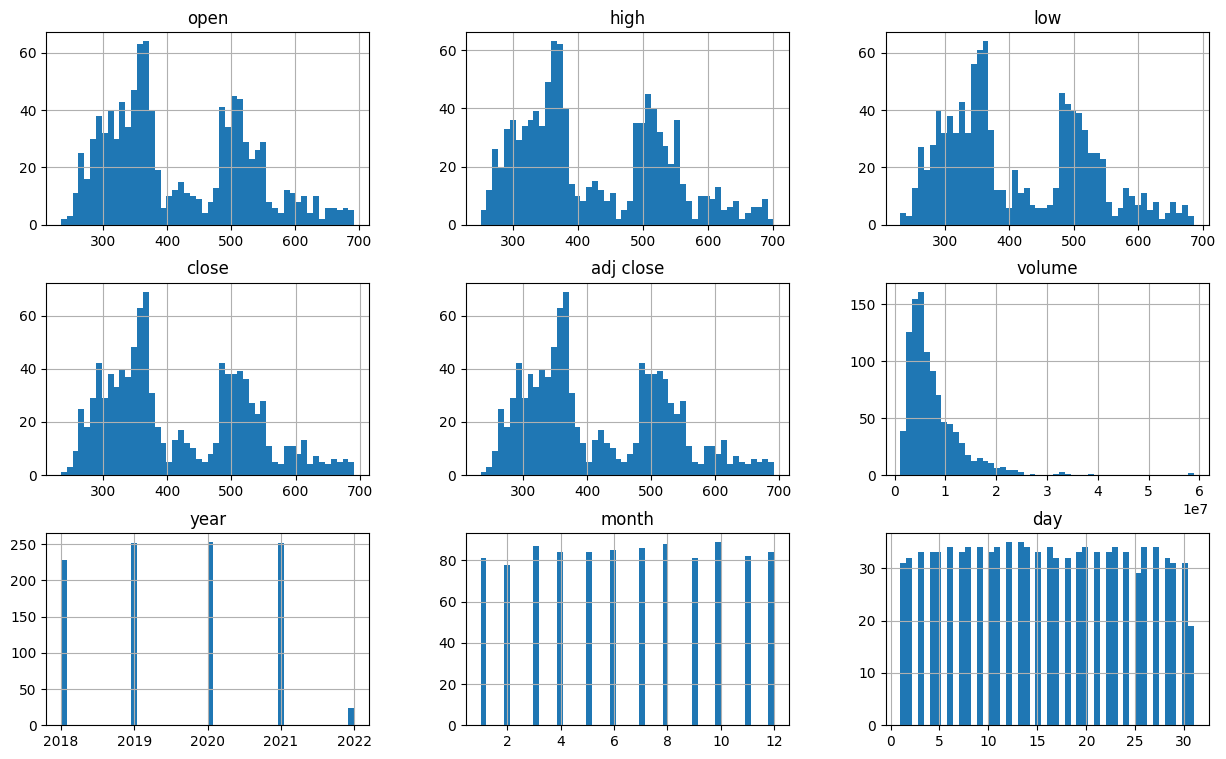

In [15]:
df.hist(figsize=(15,9),bins=50)
plt.show()

<Axes: >

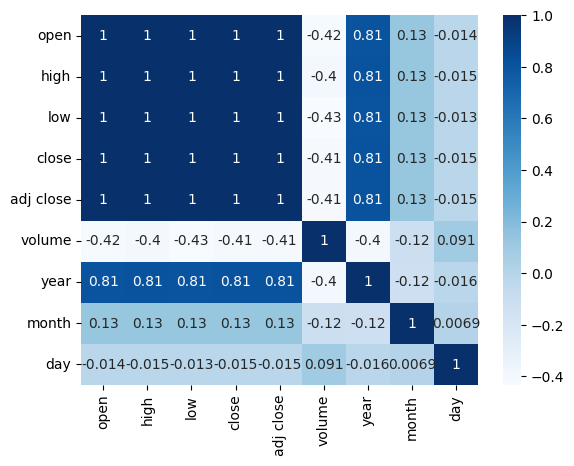

In [16]:
sns.heatmap(df.corr(),annot=True,cmap='Blues')

No clear correlation can be seen

**Model Building**

In [17]:
# splitting the data into dependent and independent variables
x = df.drop(columns = ['adj close'])
y = df['adj close']

In [18]:
x

,open,high,low,close,volume,year,month,day
0,262.000000,267.899994,250.029999,254.259995,11896100,2018,2,5
1,247.699997,266.700012,245.000000,265.720001,12595800,2018,2,6
2,266.579987,272.450012,264.329987,264.559998,8981500,2018,2,7
3,267.079987,267.619995,250.000000,250.100006,9306700,2018,2,8
4,253.850006,255.800003,236.110001,249.470001,16906900,2018,2,9
...,...,...,...,...,...,...,...,...
1004,401.970001,427.700012,398.200012,427.140015,20047500,2022,1,31
1005,432.959991,458.480011,425.540009,457.130005,22542300,2022,2,1
1006,448.250000,451.980011,426.480011,429.480011,14346000,2022,2,2
1007,421.440002,429.260010,404.279999,405.600006,9905200,2022,2,3


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [20]:
# Linear Regression
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)
lr_r2 = r2_score(y_test,lr_pred)

In [21]:
lr_r2

1.0

In [22]:
# Decision Tree

dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
dt_pred = dt.predict(x_test)
dt_r2 = r2_score(y_test,dt_pred)
dt_r2

0.9998339166061123

In [23]:
# Random Forest
rf = RandomForestRegressor()
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)
rf_r2 = r2_score(y_test,rf_pred)
rf_r2

0.9999202780254893

In [24]:
svr = SVR()
svr.fit(x_train,y_train)
svr_pred = svr.predict(x_test)
svr_r2 = r2_score(y_test,svr_pred)
svr_r2

0.29191099440485824

In [25]:
ridge = Ridge()
ridge.fit(x_train,y_train)
ridge_pred = ridge.predict(x_test)
ridge_r2 = r2_score(y_test,ridge_pred)
ridge_r2

0.9999999999901905

In [26]:
lasso = Lasso()
lasso.fit(x_train,y_train)
lasso_pred = lasso.predict(x_test)
lasso_r2 = r2_score(y_test,lasso_pred)
lasso_r2

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.277e+03, tolerance: 9.463e+02
  model = cd_fast.enet_coordinate_descent(


0.9998894214752928